In [6]:
# ==========================================
# CELL 1: SETUP, IMPORTS & DATA DOWNLOAD
# ==========================================
import kagglehub
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
from sklearn.ensemble import RandomForestClassifier
import random
import warnings
warnings.filterwarnings('ignore')

print("=== Downloading Dataset via Kagglehub ===")
# Download latest version directly to Colab
path = kagglehub.dataset_download("himadri07/ciciot2023")
print("Path to dataset files:", path)
print("Files available:", os.listdir(path))

=== Downloading Dataset via Kagglehub ===
Using Colab cache for faster access to the 'ciciot2023' dataset.
Path to dataset files: /kaggle/input/ciciot2023
Files available: ['CICIOT23']


In [9]:
# ==========================================
# CELL 2: LOAD TRAIN, VALIDATION, AND TEST DATA (AUTO-FIND FILES)
# ==========================================
import os
import pandas as pd

print("=== Loading Datasets ===")

# 1. Automatically search for the exact file names
train_path, val_path, test_path = None, None, None

# This looks through all files downloaded by kagglehub
for root, dirs, files in os.walk(path):
    for file in files:
        if 'train' in file.lower() and file.endswith('.csv'):
            train_path = os.path.join(root, file)
        elif 'val' in file.lower() and file.endswith('.csv'):
            val_path = os.path.join(root, file)
        elif 'test' in file.lower() and file.endswith('.csv'):
            test_path = os.path.join(root, file)

print(f"Found Train file at: {train_path}")
print(f"Found Val file at: {val_path}")
print(f"Found Test file at: {test_path}\n")

if not all([train_path, val_path, test_path]):
    print("❌ ERROR: Could not find all CSV files! Check the dataset folder.")
else:
    print("Loading Data (Taking advantage of RAM)...")
    # Loading the exact same number of rows to keep the comparison 100% fair
    df_train = pd.read_csv(train_path, nrows=1000000)
    df_val = pd.read_csv(val_path, nrows=200000)
    df_test = pd.read_csv(test_path, nrows=300000)

    print(f"Train shape: {df_train.shape}")
    print(f"Validation shape: {df_val.shape}")
    print(f"Test shape: {df_test.shape}\n")

=== Loading Datasets ===
Found Train file at: /kaggle/input/ciciot2023/CICIOT23/train/train.csv
Found Val file at: /kaggle/input/ciciot2023/CICIOT23/validation/validation.csv
Found Test file at: /kaggle/input/ciciot2023/CICIOT23/test/test.csv

Loading Data (Taking advantage of RAM)...
Train shape: (1000000, 47)
Validation shape: (200000, 47)
Test shape: (300000, 47)



In [10]:
# ==========================================
# CELL 3: DATA CLEANING & LABEL ENCODING
# ==========================================
print("=== Data Cleaning & Feature Separation ===")

# 1. Handle Infinity and Missing Values
for df, name in zip([df_train, df_val, df_test], ['Train', 'Validation', 'Test']):
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    df.dropna(inplace=True)
    print(f"Cleaned {name} shape: {df.shape}")

# 2. Separate Features and Targets
X_train, y_train = df_train.drop('label', axis=1), df_train['label']
X_val, y_val = df_val.drop('label', axis=1), df_val['label']
X_test, y_test = df_test.drop('label', axis=1), df_test['label']

# 3. Label Encoding
print("\nEncoding target labels into numeric values...")
label_encoder = LabelEncoder()
label_encoder.fit(pd.concat([y_train, y_val, y_test]))

y_train_encoded = label_encoder.transform(y_train)
y_val_encoded = label_encoder.transform(y_val)
y_test_encoded = label_encoder.transform(y_test)

print("Encoding complete!")

=== Data Cleaning & Feature Separation ===
Cleaned Train shape: (1000000, 47)
Cleaned Validation shape: (200000, 47)
Cleaned Test shape: (300000, 47)

Encoding target labels into numeric values...
Encoding complete!


In [11]:
# ==========================================
# CELL 4: FEATURE SCALING
# ==========================================
print("=== Consistent Feature Scaling ===")

scaler = StandardScaler()
print("Fitting scaler on Training data and transforming all sets to prevent data leakage...")
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("Scaling complete! Data is ready for the model.")

=== Consistent Feature Scaling ===
Fitting scaler on Training data and transforming all sets to prevent data leakage...
Scaling complete! Data is ready for the model.


In [12]:
# ==========================================
# CELL 5: RANDOM FOREST TRAINING
# ==========================================
print("=== Training Random Forest Classifier ===")

# n_jobs=-1 forces Colab to use all available CPU cores to speed up the process.
# verbose=2 will print out the progress so you know it hasn't frozen.
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    verbose=2
)

print("Training the model (Note: This runs on CPU and will take longer than XGBoost GPU)...")
rf_model.fit(X_train_scaled, y_train_encoded)

print("\nRandom Forest Training Complete!")

=== Training Random Forest Classifier ===
Training the model (Note: This runs on CPU and will take longer than XGBoost GPU)...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 2 concurrent workers.


building tree 1 of 100building tree 2 of 100

building tree 3 of 100
building tree 4 of 100
building tree 5 of 100
building tree 6 of 100
building tree 7 of 100
building tree 8 of 100
building tree 9 of 100
building tree 10 of 100
building tree 11 of 100
building tree 12 of 100
building tree 13 of 100
building tree 14 of 100
building tree 15 of 100
building tree 16 of 100
building tree 17 of 100
building tree 18 of 100
building tree 19 of 100
building tree 20 of 100
building tree 21 of 100
building tree 22 of 100
building tree 23 of 100
building tree 24 of 100
building tree 25 of 100
building tree 26 of 100
building tree 27 of 100
building tree 28 of 100
building tree 29 of 100
building tree 30 of 100
building tree 31 of 100
building tree 32 of 100
building tree 33 of 100
building tree 34 of 100
building tree 35 of 100
building tree 36 of 100
building tree 37 of 100
building tree 38 of 100
building tree 39 of 100


[Parallel(n_jobs=-1)]: Done  37 tasks      | elapsed:  1.1min


building tree 40 of 100
building tree 41 of 100
building tree 42 of 100
building tree 43 of 100
building tree 44 of 100
building tree 45 of 100
building tree 46 of 100
building tree 47 of 100
building tree 48 of 100
building tree 49 of 100
building tree 50 of 100
building tree 51 of 100
building tree 52 of 100
building tree 53 of 100
building tree 54 of 100
building tree 55 of 100
building tree 56 of 100
building tree 57 of 100
building tree 58 of 100
building tree 59 of 100
building tree 60 of 100
building tree 61 of 100
building tree 62 of 100
building tree 63 of 100
building tree 64 of 100
building tree 65 of 100
building tree 66 of 100
building tree 67 of 100
building tree 68 of 100
building tree 69 of 100
building tree 70 of 100
building tree 71 of 100
building tree 72 of 100
building tree 73 of 100
building tree 74 of 100
building tree 75 of 100
building tree 76 of 100
building tree 77 of 100
building tree 78 of 100
building tree 79 of 100
building tree 80 of 100
building tree 81

[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:  3.1min finished


=== Evaluating on Unseen Test Data ===


[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  37 tasks      | elapsed:    6.1s
[Parallel(n_jobs=2)]: Done 100 out of 100 | elapsed:   16.1s finished



             Random Forest Model Results             
Accuracy : 0.9934  (99.34%)
F1-Score : 0.9929  (99.29%)

Classification Report:
                         precision    recall  f1-score   support

       Backdoor_Malware       0.67      0.08      0.14        25
          BenignTraffic       0.88      0.98      0.93      6984
       BrowserHijacking       0.78      0.21      0.33        34
       CommandInjection       0.71      0.16      0.26        31
 DDoS-ACK_Fragmentation       1.00      0.99      0.99      1825
        DDoS-HTTP_Flood       0.98      0.93      0.95       170
        DDoS-ICMP_Flood       1.00      1.00      1.00     46157
DDoS-ICMP_Fragmentation       0.99      0.99      0.99      2942
      DDoS-PSHACK_Flood       1.00      1.00      1.00     26448
       DDoS-RSTFINFlood       1.00      1.00      1.00     25982
         DDoS-SYN_Flood       1.00      1.00      1.00     26011
         DDoS-SlowLoris       0.83      0.99      0.90       158
DDoS-SynonymousIP_F

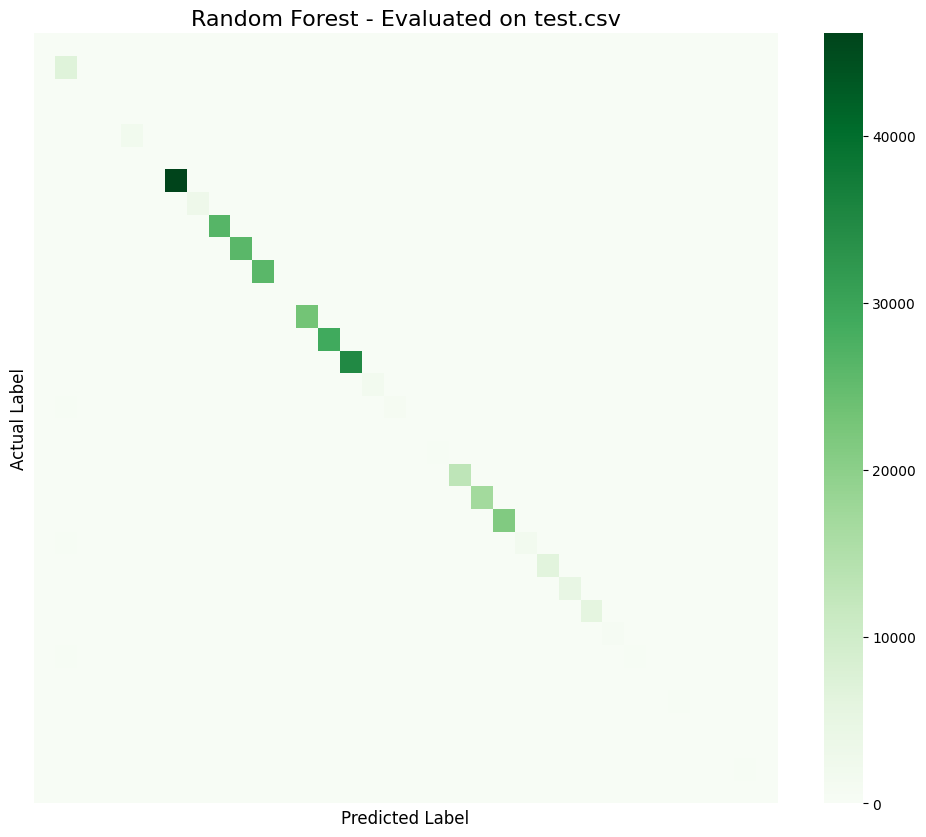


Random Forest Evaluation executed successfully!


In [13]:
# ==========================================
# CELL 6: EVALUATION AND VISUALIZATION
# ==========================================
print("=== Evaluating on Unseen Test Data ===")

y_pred = rf_model.predict(X_test_scaled)

print("\n" + "="*50)
print("             Random Forest Model Results             ")
print("="*50)

accuracy = accuracy_score(y_test_encoded, y_pred)
f1 = f1_score(y_test_encoded, y_pred, average='weighted')

print(f"Accuracy : {accuracy:.4f}  ({(accuracy*100):.2f}%)")
print(f"F1-Score : {f1:.4f}  ({(f1*100):.2f}%)\n")

# Dynamically handle labels present in the test set
present_labels = np.unique(np.concatenate((y_test_encoded, y_pred)))
present_target_names = label_encoder.inverse_transform(present_labels)

warnings.filterwarnings('ignore', category=UserWarning)
print("Classification Report:")
print(classification_report(y_test_encoded, y_pred, labels=present_labels, target_names=present_target_names))

# Confusion Matrix Heatmap
print("\nGenerating Confusion Matrix Plot...")
cm = confusion_matrix(y_test_encoded, y_pred)

plt.figure(figsize=(12, 10))
# Using 'Greens' instead of 'Blues' so you can easily visually distinguish this model from XGBoost in your report
sns.heatmap(cm, annot=False, cmap='Greens', xticklabels=False, yticklabels=False)
plt.title('Random Forest - Evaluated on test.csv', fontsize=16)
plt.ylabel('Actual Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.show()

print("\nRandom Forest Evaluation executed successfully!")

=== Extracting Feature Importance ===


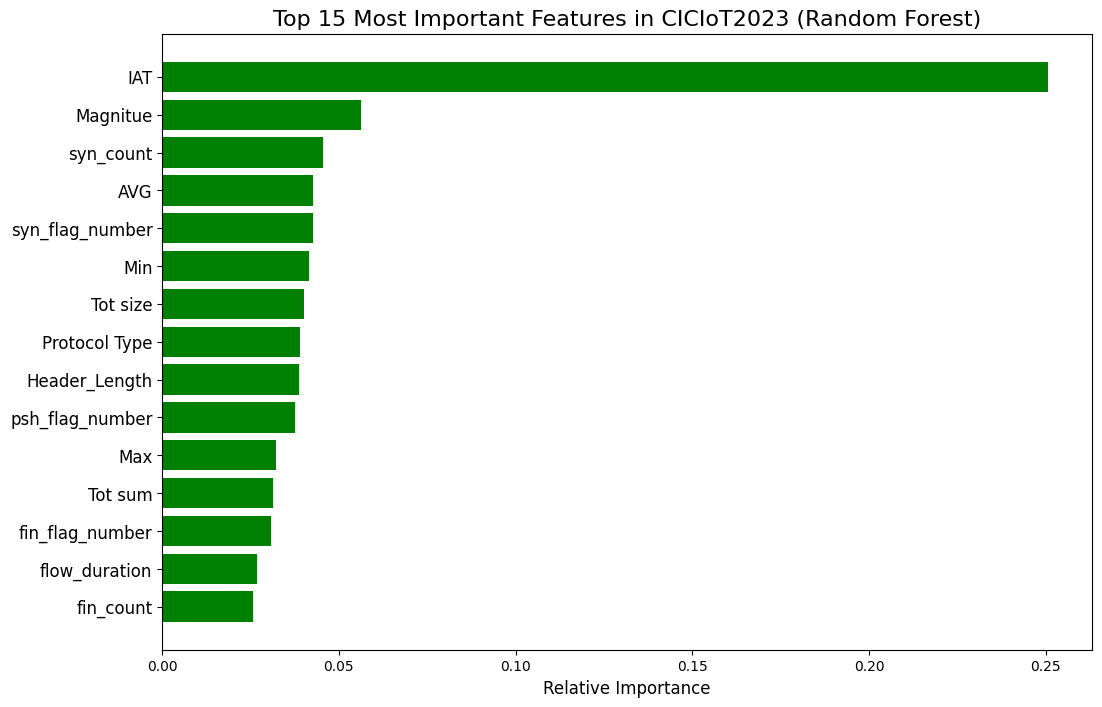

Dimensionality Analysis: These top features contribute the most to the Random Forest model's decisions.


In [14]:
# ==========================================
# CELL 7: FEATURE IMPORTANCE (RUBRIC REQUIREMENT)
# ==========================================
print("=== Extracting Feature Importance ===")

# Get feature importances from the trained Random Forest model
importances = rf_model.feature_importances_
feature_names = X_train.columns

# Sort the feature importances in descending order and get the top 15
indices = np.argsort(importances)[-15:]

plt.figure(figsize=(12, 8))
plt.title('Top 15 Most Important Features in CICIoT2023 (Random Forest)', fontsize=16)
plt.barh(range(len(indices)), importances[indices], color='g', align='center')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices], fontsize=12)
plt.xlabel('Relative Importance', fontsize=12)
plt.show()

print("Dimensionality Analysis: These top features contribute the most to the Random Forest model's decisions.")

In [15]:
# ==========================================
# VIEW LABEL ENCODING MAPPING
# ==========================================
print("=== Target Label Mapping (Number -> Attack Name) ===\n")

# Extract the classes from the fitted LabelEncoder
for index, attack_name in enumerate(label_encoder.classes_):
    print(f"Number {index:2d}  --->  {attack_name}")

=== Target Label Mapping (Number -> Attack Name) ===

Number  0  --->  Backdoor_Malware
Number  1  --->  BenignTraffic
Number  2  --->  BrowserHijacking
Number  3  --->  CommandInjection
Number  4  --->  DDoS-ACK_Fragmentation
Number  5  --->  DDoS-HTTP_Flood
Number  6  --->  DDoS-ICMP_Flood
Number  7  --->  DDoS-ICMP_Fragmentation
Number  8  --->  DDoS-PSHACK_Flood
Number  9  --->  DDoS-RSTFINFlood
Number 10  --->  DDoS-SYN_Flood
Number 11  --->  DDoS-SlowLoris
Number 12  --->  DDoS-SynonymousIP_Flood
Number 13  --->  DDoS-TCP_Flood
Number 14  --->  DDoS-UDP_Flood
Number 15  --->  DDoS-UDP_Fragmentation
Number 16  --->  DNS_Spoofing
Number 17  --->  DictionaryBruteForce
Number 18  --->  DoS-HTTP_Flood
Number 19  --->  DoS-SYN_Flood
Number 20  --->  DoS-TCP_Flood
Number 21  --->  DoS-UDP_Flood
Number 22  --->  MITM-ArpSpoofing
Number 23  --->  Mirai-greeth_flood
Number 24  --->  Mirai-greip_flood
Number 25  --->  Mirai-udpplain
Number 26  --->  Recon-HostDiscovery
Number 27  --->  Reco

In [16]:
# ==========================================
# CELL 9: TEST THE MODEL WITH A SINGLE RECORD (VIVA / VIDEO DEMO)
# ==========================================
print("=== Real-time Intrusion Detection Demo ===\n")

# 1. Test Dataset එකෙන් අහඹු ලෙස එක පේළියක් (Single record) තෝරාගැනීම
random_index = random.randint(0, len(X_test) - 1)
sample_packet = X_test.iloc[[random_index]]

# ඇත්තටම ඒක මොන ප්‍රහාරයක්ද කියලා අපි හොයාගන්නවා (හැබැයි Model එකට කියන්නේ නෑ)
actual_label_encoded = y_test_encoded[random_index]
actual_label_text = label_encoder.inverse_transform([actual_label_encoded])[0]

print(f"Selected Packet Index: {random_index}")
print(f"ACTUAL Traffic Type (Hidden from Model): {actual_label_text}\n")

# 2. දත්ත Preprocess කිරීම (Scaling)
sample_packet_scaled = scaler.transform(sample_packet)

# 3. Model එකෙන් අනුමාන කිරීම (Prediction)
print("Analyzing network packet through Random Forest Model...")
predicted_label_encoded = rf_model.predict(sample_packet_scaled)
predicted_label_text = label_encoder.inverse_transform(predicted_label_encoded)[0]

# 4. ප්‍රතිඵලය පෙන්වීම
print("-" * 50)
print(f"🛡️ MODEL PREDICTION: {predicted_label_text}")
print("-" * 50)

if actual_label_text == predicted_label_text:
    print("\n✅ SUCCESS: The model correctly identified the network traffic!")
else:
    print("\n❌ FAILED: The model misclassified the network traffic.")

=== Real-time Intrusion Detection Demo ===

Selected Packet Index: 227537
ACTUAL Traffic Type (Hidden from Model): DDoS-RSTFINFlood

Analyzing network packet through Random Forest Model...
--------------------------------------------------
🛡️ MODEL PREDICTION: DDoS-RSTFINFlood
--------------------------------------------------

✅ SUCCESS: The model correctly identified the network traffic!


[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  37 tasks      | elapsed:    0.1s
[Parallel(n_jobs=2)]: Done 100 out of 100 | elapsed:    0.1s finished


In [17]:
# ==========================================
# CELL 10: MANUAL PACKET INSPECTION & VERIFICATION
# ==========================================
print("=== Cross-Checking Model vs Actual Dataset ===\n")

# ඔයාට පරීක්ෂා කරන්න ඕනේ පේළියේ අංකය මෙතන දෙන්න
row_number = 550

my_packet = X_test.iloc[[row_number]]
actual_label = y_test.iloc[row_number]

print("--- 1. Original Dataset එකේ තියෙන ඇත්තම විස්තර ---")
print(f"තෝරාගත් පේළි අංකය (Index): {row_number}")
print(f"Dataset එකේ තියෙන ඇත්තම Attack එක: ** {actual_label} **")
print(f"මේ Packet එකේ Flow Duration එක: {my_packet['flow_duration'].values[0]}")
print(f"මේ Packet එකේ Header Length එක: {my_packet['Header_Length'].values[0]}\n")

print("--- 2. Model එකේ අනුමානය (Prediction) ---")
my_packet_scaled = scaler.transform(my_packet)
predicted_encoded = rf_model.predict(my_packet_scaled)
predicted_label = label_encoder.inverse_transform(predicted_encoded)[0]

print(f"Model එක අනුමාන කරපු Attack එක: ** {predicted_label} **\n")

print("--- 3. අවසන් නිගමනය ---")
if actual_label == predicted_label:
    print(f"✅ SUCCESS: Dataset එකේ තියෙන '{actual_label}' කියන එකමයි Model එකත් කිව්වේ! Model එක 100% නිවැරදියි.")
else:
    print(f"❌ FAILED: Dataset එකේ තියෙන්නේ '{actual_label}' වුණාට, Model එක කිව්වේ '{predicted_label}' කියලා.")

=== Cross-Checking Model vs Actual Dataset ===

--- 1. Original Dataset එකේ තියෙන ඇත්තම විස්තර ---
තෝරාගත් පේළි අංකය (Index): 550
Dataset එකේ තියෙන ඇත්තම Attack එක: ** DDoS-SynonymousIP_Flood **
මේ Packet එකේ Flow Duration එක: 0.1311020565032959
මේ Packet එකේ Header Length එක: 75.6

--- 2. Model එකේ අනුමානය (Prediction) ---
Model එක අනුමාන කරපු Attack එක: ** DDoS-SynonymousIP_Flood **

--- 3. අවසන් නිගමනය ---
✅ SUCCESS: Dataset එකේ තියෙන 'DDoS-SynonymousIP_Flood' කියන එකමයි Model එකත් කිව්වේ! Model එක 100% නිවැරදියි.


[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  37 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 100 out of 100 | elapsed:    0.0s finished
